# Vehicle Market Analysis (2001–2024)


## Introduction

The purpose of this notebook is to perform a detailed analysis of vehicle registrations by body type and fuel type over the period 2001–2024.  
The main objectives include:  

1. Exploring **overall market trends** and the impact of economic events on vehicle sales.  
2. Analyzing **seasonality of registrations** and identifying peak periods by quarter.  
3. Studying **fuel type trends** and the growth of alternative energy vehicles (hybrids and electric vehicles).  
4. Reviewing **brand market positions**, identifying consistent leaders and emerging popular brands.  
5. Drawing conclusions to support **strategic planning and sales forecasting**.  



## Data Import

In [1]:
#import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.interpolate import make_interp_spline
from scipy.signal import find_peaks

sns.set(style='whitegrid')

In [3]:
#get file from here
#https://www.gov.uk/government/statistical-data-sets/vehicle-licensing-statistics-data-files df_VEH0160_GB
#Vehicles registered for the first time by body type, make, generic model and model: Great Britain

df_raw = pd.read_csv('df_VEH0160_GB.csv', sep=',')
df_raw.info()
df_raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102892 entries, 0 to 102891
Columns: 102 entries, BodyType to 2001Q1
dtypes: int64(97), object(5)
memory usage: 80.1+ MB


,BodyType,Make,GenModel,Model,Fuel,2025Q1,2024Q4,2024Q3,2024Q2,2024Q1,...,2003Q2,2003Q1,2002Q4,2002Q3,2002Q2,2002Q1,2001Q4,2001Q3,2001Q2,2001Q1
0,Cars,ABARTH,ABARTH 124,124 GT MULTIAIR,Petrol,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Cars,ABARTH,ABARTH 124,124 GT MULTIAIR AUTO,Petrol,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Cars,ABARTH,ABARTH SPIDER,124 SPIDER MULTIAIR,Petrol,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Cars,ABARTH,ABARTH SPIDER,124 SPIDER MULTIAIR AUTO,Petrol,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Cars,ABARTH,ABARTH SPIDER,124 SPIDER SCORPIONE MULTIAIR,Petrol,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Data Cleaning

In [4]:
df = df_raw.drop('2025Q1', axis=1)

In [5]:
#check missing values
print(df.isna().sum())

BodyType    0
Make        0
GenModel    1
Model       0
Fuel        0
           ..
2002Q1      0
2001Q4      0
2001Q3      0
2001Q2      0
2001Q1      0
Length: 101, dtype: int64


In [6]:
df[['GenModel']] = df[['GenModel']].fillna("MISSING")

In [7]:
# Convert wide to long format for time series analysis
df_long = df.melt(
    id_vars=["BodyType","Make","GenModel", "Model","Fuel"],
    var_name="YearQuarter",
    value_name="Registrations"
)

In [8]:
df_long.head()

,BodyType,Make,GenModel,Model,Fuel,YearQuarter,Registrations
0,Cars,ABARTH,ABARTH 124,124 GT MULTIAIR,Petrol,2024Q4,0
1,Cars,ABARTH,ABARTH 124,124 GT MULTIAIR AUTO,Petrol,2024Q4,0
2,Cars,ABARTH,ABARTH SPIDER,124 SPIDER MULTIAIR,Petrol,2024Q4,0
3,Cars,ABARTH,ABARTH SPIDER,124 SPIDER MULTIAIR AUTO,Petrol,2024Q4,0
4,Cars,ABARTH,ABARTH SPIDER,124 SPIDER SCORPIONE MULTIAIR,Petrol,2024Q4,0


In [9]:
df_long['YearQuarter'].value_counts()


YearQuarter
2024Q4    102892
2024Q3    102892
2007Q2    102892
2007Q3    102892
2007Q4    102892
           ...  
2017Q3    102892
2017Q4    102892
2018Q1    102892
2018Q2    102892
2001Q1    102892
Name: count, Length: 96, dtype: int64

In [10]:
qtr = df_long["YearQuarter"]

years = qtr.str[:4].astype(int)
quarters = qtr.str[-1].astype(int)

months = quarters * 3

df_long["Date"] = pd.to_datetime(years*10000 + months*100 + 1, format="%Y%m%d") + pd.offsets.MonthEnd(0)
df_long["Year"] = df_long["YearQuarter"].str[:4].astype(int)


In [11]:
df_long["Quarter"] = pd.PeriodIndex(df_long["Date"], freq="Q").quarter

In [12]:
df_long.head()

,BodyType,Make,GenModel,Model,Fuel,YearQuarter,Registrations,Date,Year,Quarter
0,Cars,ABARTH,ABARTH 124,124 GT MULTIAIR,Petrol,2024Q4,0,2024-12-31,2024,4
1,Cars,ABARTH,ABARTH 124,124 GT MULTIAIR AUTO,Petrol,2024Q4,0,2024-12-31,2024,4
2,Cars,ABARTH,ABARTH SPIDER,124 SPIDER MULTIAIR,Petrol,2024Q4,0,2024-12-31,2024,4
3,Cars,ABARTH,ABARTH SPIDER,124 SPIDER MULTIAIR AUTO,Petrol,2024Q4,0,2024-12-31,2024,4
4,Cars,ABARTH,ABARTH SPIDER,124 SPIDER SCORPIONE MULTIAIR,Petrol,2024Q4,0,2024-12-31,2024,4


In [13]:
#checkpoint
result_df = df_long.copy()

# Feature Engineering

In [14]:
#total registrations by year:
yearly = result_df.groupby('Year')['Registrations'].sum().reset_index()
yearly.head()

,Year,Registrations
0,2001,3137731
1,2002,3229387
2,2003,3231897
3,2004,3185437
4,2005,3021374


In [15]:
#top car brands by total sales
top_makes = (result_df.groupby('Make')['Registrations']
             .sum()
             .sort_values(ascending=False)
             .head(10)
             .index)
df_top10 = result_df[result_df['Make'].isin(top_makes)].copy()
df_top10_grouped = df_top10.groupby(['Year', 'Make'], as_index=False)['Registrations'].sum()
df_top10_grouped = df_top10_grouped.sort_values('Year')

In [16]:
#total by fuel type:
fuel_yearly = result_df.groupby(['Year','Fuel'])['Registrations'].sum().unstack(fill_value=0)
fuel_yearly.head()

Fuel,Battery electric,Diesel,Fuel cell electric,Gas,Hybrid electric (diesel),Hybrid electric (petrol),Other fuel types,Petrol,Plug-in hybrid electric (diesel),Plug-in hybrid electric (petrol),Range extended electric
Year,,,,,,,,,,,
2001,559,814511,2,3630,4,636,116,2318268,0,5,0
2002,506,999955,3,4182,3,291,115,2224330,0,2,0
2003,584,1132846,3,6820,1,383,72,2091188,0,0,0
2004,570,1275651,4,4309,4,1560,78,1903261,0,0,0
2005,746,1315177,8,2404,6,5376,80,1697577,0,0,0


In [17]:
#aggregate sales by quarter
quarter = result_df.groupby(['Year','Quarter'])['Registrations'].sum().reset_index()
quarter.head()

,Year,Quarter,Registrations
0,2001,1,839071
1,2001,2,766034
2,2001,3,884174
3,2001,4,648452
4,2002,1,890652


# Visualization and Analysis

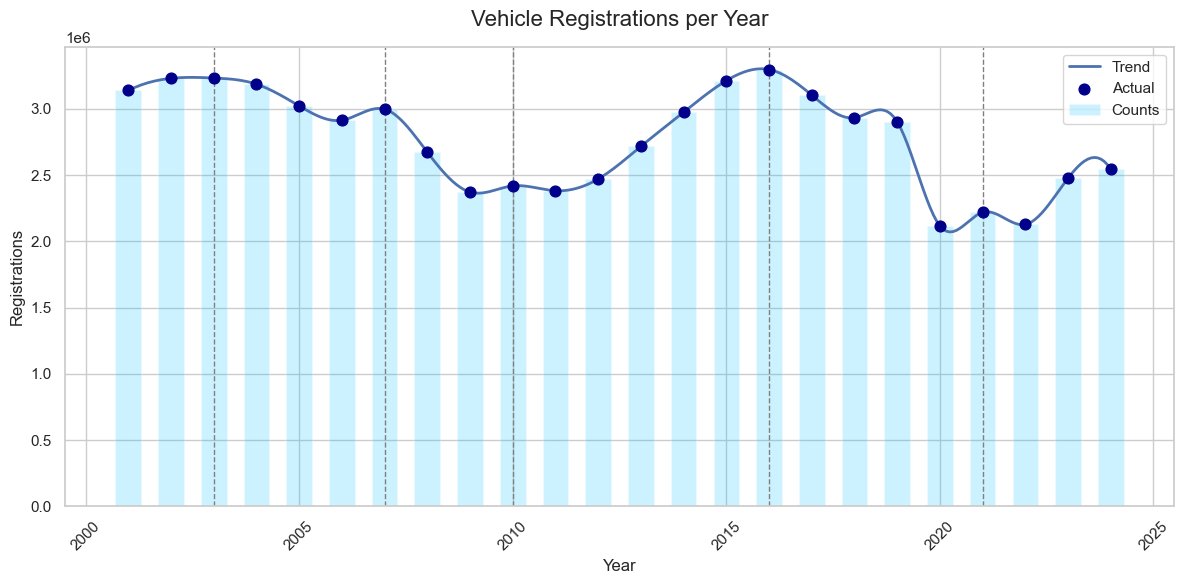

In [18]:
#Vehicle Registrations per Year

x = yearly['Year'].values
y = yearly['Registrations'].values

#cubic spline
x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_smooth)

#identify maxima, minima
peak_indices, _ = find_peaks(y, distance=1) 
peak_years = x[peak_indices]
peak_values = y[peak_indices]
dip_indices, _ = find_peaks(-y, distance=1)
dip_years = x[dip_indices]
dip_values = y[dip_indices]


plt.figure(figsize=(12,6))

plt.plot(x_smooth, y_smooth, color='b', linewidth=2, label='Trend')
plt.scatter(x, y, color='darkblue', s=60, zorder=5, label='Actual')
plt.bar(x, y, alpha=0.2, color='deepskyblue', width=0.6, label='Counts')

for p_x, p_y in zip(peak_years, peak_values):
    plt.axvline(p_x, color='grey', linestyle='--', linewidth=1)

plt.title('Vehicle Registrations per Year', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Registrations', fontsize=12)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


The graph shows annual vehicle registrations with noticeable peaks around 2003–2004 and 2015–2016, and significant drops around 2008–2009 and 2020, which could correspond to economic downturns (global financial crisis) and COVID-19). Overall, registrations fluctuate between 2.5–3.3 million, showing a cyclical pattern of growth and slight declines. Recent years indicate recovery after 2020, though still below pre-2020 peaks. Major events, trend lines, and actual counts could be highlighted for clearer interpretation.

## Cars Brands Popularity

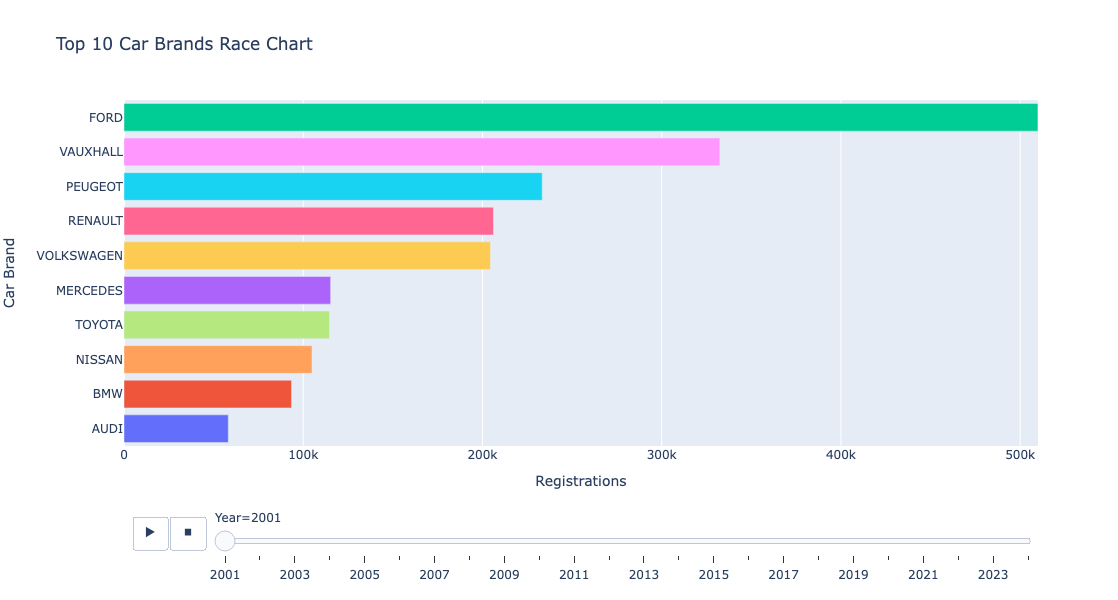

In [19]:
#top 10 Car Brands Race Chart

fig = px.bar(
    df_top10_grouped,
    x='Registrations',
    y='Make',
    color='Make',
    orientation='h',
    animation_frame='Year',
    range_x=[0, df_top10_grouped['Registrations'].max() + 50],
    title='Top 10 Car Brands Race Chart',
    labels={'Make':'Car Brand'},
    height=600
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    showlegend=False
)

fig.show()

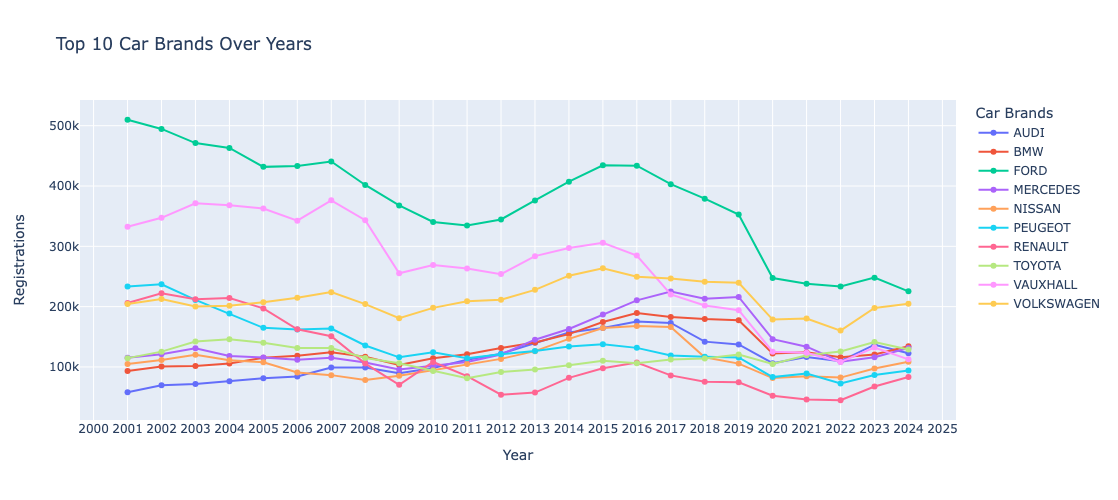

In [20]:
#top 10 Car Brands Over Years
fig = px.line(df_top10_grouped,
              x='Year',
              y='Registrations',
              color='Make',
              markers=True,  
              labels={'Make':'Car Brand'},
              title='Top 10 Car Brands Over Years')

fig.update_layout(
    xaxis=dict(dtick=1), 
    yaxis_title='Registrations',
    legend_title='Car Brands',
    height=500
)

fig.show()

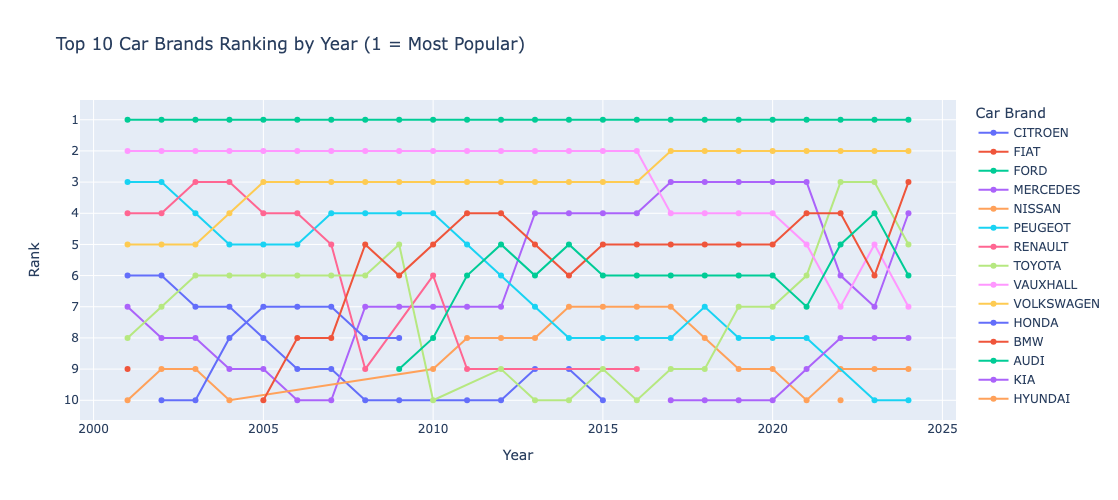

In [21]:
#top 10 Car Brands Ranking by Year

df = result_df.copy()

def rank_top10(df):
    ranked_list = []
    for year in df['Year'].sort_values().unique():
        df_year = df[df['Year'] == year]
        
        df_year = df_year.groupby('Make', as_index=False)['Registrations'].sum()
        df_year['Rank'] = df_year['Registrations'].rank(method='min', ascending=False)

        df_year = df_year[df_year['Rank'] <= 10]
        ranked_list.append(df_year.assign(Year=year))
    return pd.concat(ranked_list)

df_ranked = rank_top10(df)

fig = px.line(df_ranked,
              x='Year',
              y='Rank',
              color='Make',
              markers=True,
              labels={'Make':'Car Brand'},
              title='Top 10 Car Brands Ranking by Year (1 = Most Popular)')

fig.update_yaxes(autorange="reversed", dtick=1)

fig.update_layout(
    yaxis_title='Rank',
    xaxis_title='Year',
    height=500
)

fig.show()

In [22]:
years = sorted(df_ranked['Year'].unique())

leaders = df_ranked[df_ranked['Rank'] == 1][['Year', 'Make']]
print("Leaders by years:")
print(leaders)

top10_sets = [set(df_ranked[df_ranked['Year']==y]['Make']) for y in years]
stable_top10 = set.intersection(*top10_sets)
print("\nThe top 10 most consistent brands (all years):")
print(stable_top10)

all_makes_by_year = [set(df_ranked[df_ranked['Year']==y]['Make']) for y in years]
newcomers = set()
for i in range(1, len(all_makes_by_year)):
    new_in_year = all_makes_by_year[i] - set.union(*all_makes_by_year[:i])
    newcomers.update(new_in_year)
print("\nNew brands in the top 10 by year:")
print(newcomers)

initial_top10 = all_makes_by_year[0]
eventually_out = set()
for i in range(1, len(all_makes_by_year)):
    eventually_out.update(initial_top10 - all_makes_by_year[i])
print("\nBrands that have lost popularity:")
print(eventually_out)


Leaders by years:
     Year  Make
259  2001  FORD
259  2002  FORD
259  2003  FORD
259  2004  FORD
259  2005  FORD
259  2006  FORD
259  2007  FORD
259  2008  FORD
259  2009  FORD
259  2010  FORD
259  2011  FORD
259  2012  FORD
259  2013  FORD
259  2014  FORD
259  2015  FORD
259  2016  FORD
259  2017  FORD
259  2018  FORD
259  2019  FORD
259  2020  FORD
259  2021  FORD
259  2022  FORD
259  2023  FORD
259  2024  FORD

The top 10 most consistent brands (all years):
{'FORD', 'VOLKSWAGEN', 'VAUXHALL', 'MERCEDES'}

New brands in the top 10 by year:
{'HONDA', 'HYUNDAI', 'KIA', 'AUDI', 'BMW'}

Brands that have lost popularity:
{'PEUGEOT', 'TOYOTA', 'CITROEN', 'FIAT', 'NISSAN', 'RENAULT'}


### Insights
   - Ford - **leader over the years**  consistently holds the **1st rank** from 2001 to 2024, indicating long-term popularity and market dominance.
   - Vauxhall, Mercedes and Volkswagen consistently remain in the **top 10** across all years. These brands are reliable market leaders that enjoy stable consumer trust.
   - **Newcomers** KIA, Audi, Honda, BMW and Hyundai entered the top 10 in later years. This highlights the **growing popularity of new brands** and potential shifts in market trends.
   - Nissan, Toyota, Peugeot, Fiat, Citroën and Renault dropped out of the top 10.  This indicates **declining demand** or changing consumer preferences for these brands.

## Fuel Analysis

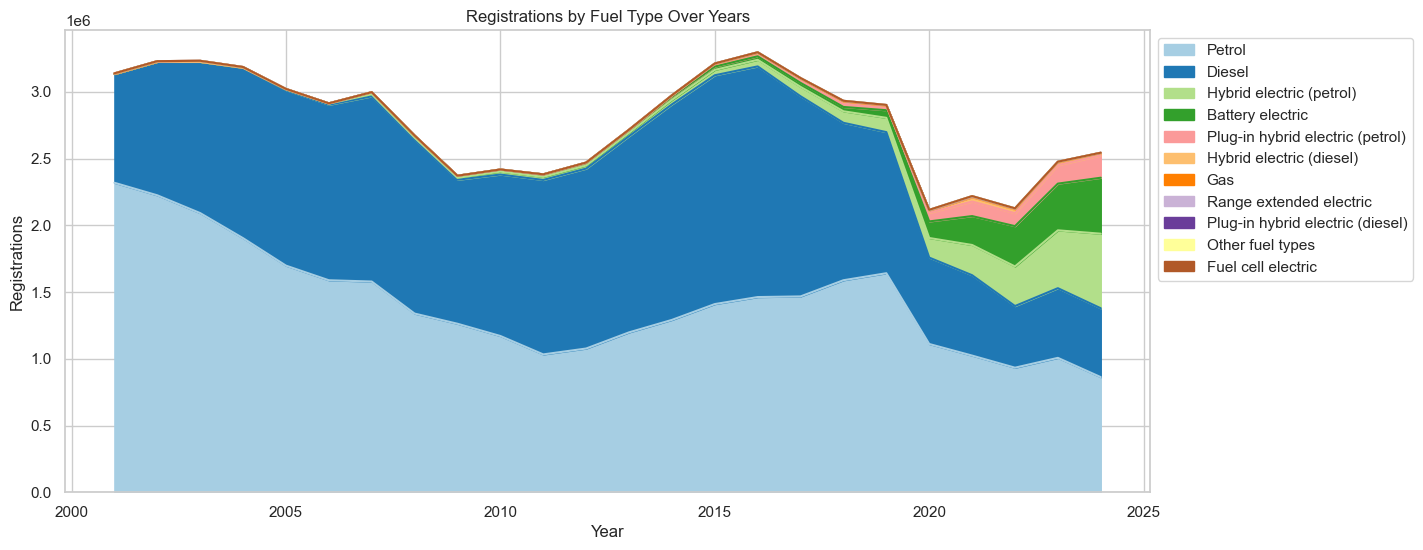

In [23]:
#registrations by Fuel Type Over Years - area plot
fuel_order = fuel_yearly.sum().sort_values(ascending=False).index
fuel_yearly_sorted = fuel_yearly[fuel_order]

fuel_yearly_sorted.plot(kind='area', stacked=True, figsize=(14,6), colormap='Paired')

plt.title('Registrations by Fuel Type Over Years')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.ylabel('Registrations')
plt.xlabel('Year')
plt.show()

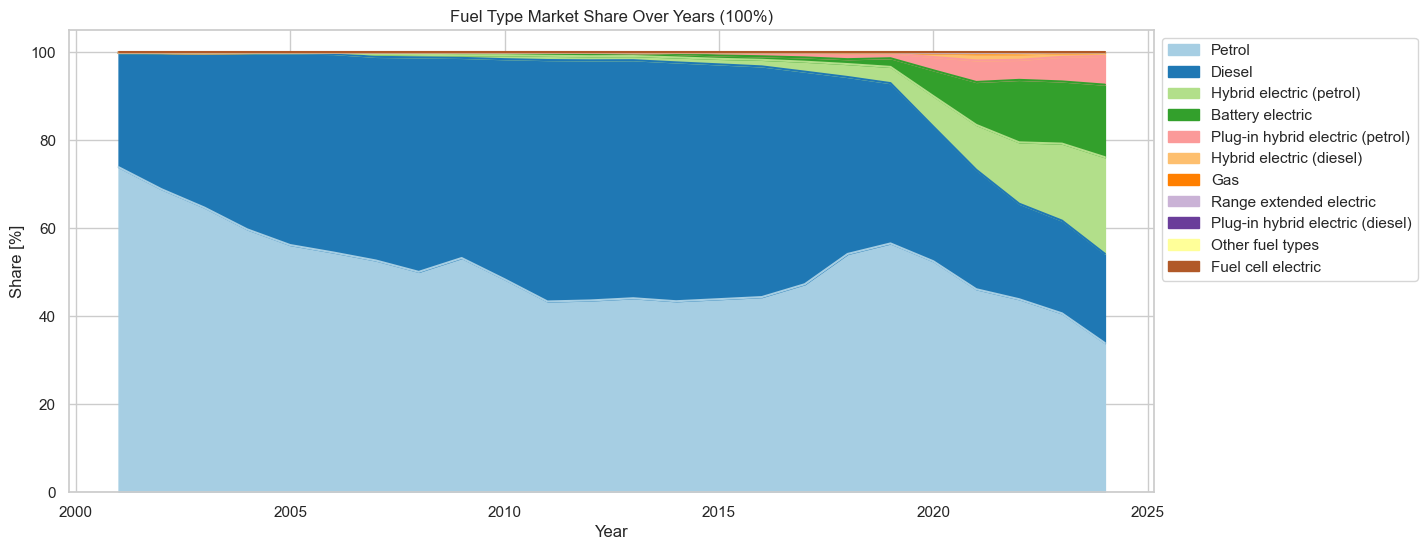

In [24]:
#fuel Type Market Share Over Years in percents
fuel_share = fuel_yearly_sorted.div(fuel_yearly.sum(axis=1), axis=0) * 100

fuel_share.plot(kind='area', stacked=True, figsize=(14,6), colormap='Paired')
plt.title('Fuel Type Market Share Over Years (100%)')
plt.ylabel('Share [%]')
plt.xlabel('Year')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.show()

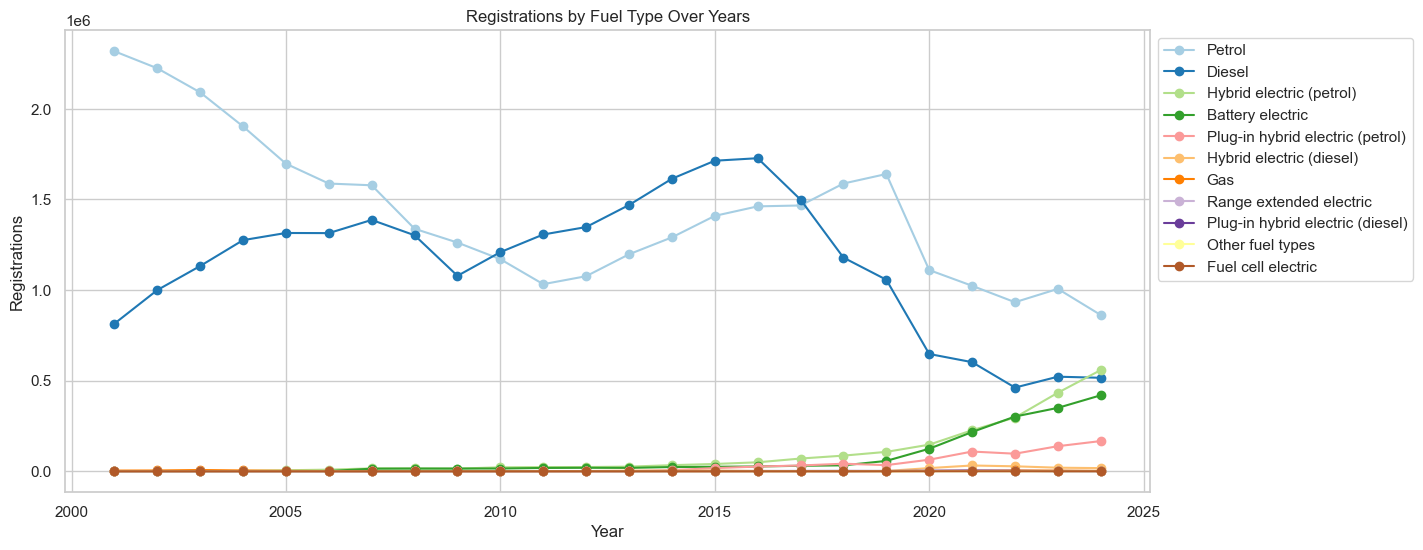

In [25]:
#Registrations by Fuel Type Over Years line plot
fuel_yearly_sorted.plot(kind='line', figsize=(14,6), marker='o', colormap='Paired')
plt.title('Registrations by Fuel Type Over Years')
plt.ylabel('Registrations')
plt.xlabel('Year')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.show()


The charts show the relative market share of each fuel type over time.

- In the early 2000s, petrol and **diesel dominated** the market.
- Diesel peaked around 2015 but declined sharply afterwards.
- Hybrid and electric powertrains grew rapidly after 2015, with battery electric vehicles showing the fastest increase after 2020.

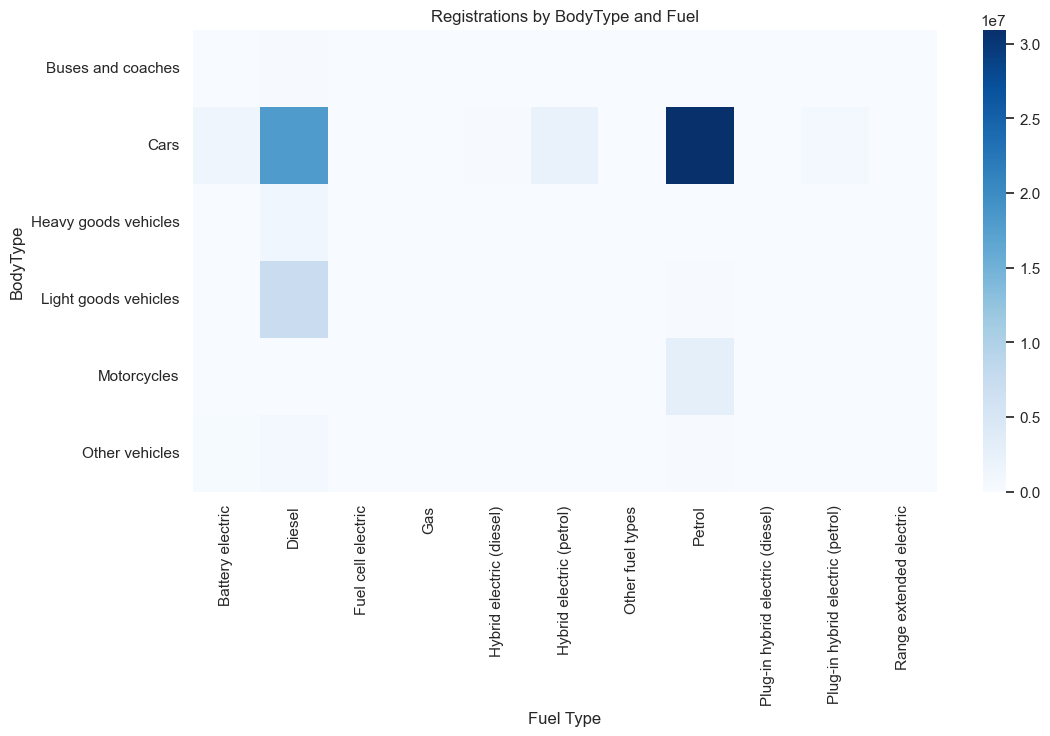

In [26]:
#BodyType and Fuel correlation
body_fuel_pivot = (
    result_df.groupby(['BodyType', 'Fuel'])['Registrations']
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))
sns.heatmap(body_fuel_pivot, annot=False, fmt='g', cmap='Blues')
plt.title('Registrations by BodyType and Fuel')
plt.xlabel('Fuel Type')
plt.ylabel('BodyType')
plt.show()

- The heatmap shows the distribution of vehicle registrations by body type and fuel type. Cars dominate the dataset, with petrol and diesel as the most common fuels. Light goods vehicles are also significant, mainly diesel-powered, while other body types such as buses, motorcycles, and heavy goods vehicles appear in smaller volumes.
- The results highlight the continued reliance on petrol and diesel in most body types, especially cars and light goods vehicles. Alternative fuels (electric, hybrid, fuel cell) are present but still represent a relatively small share, suggesting an early-stage transition toward sustainable mobility.

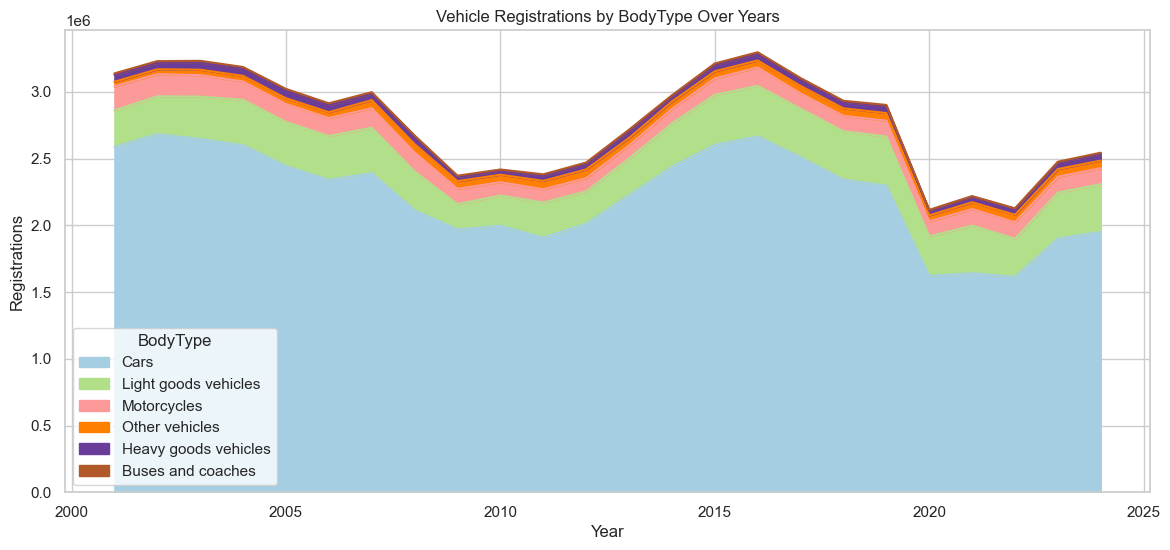

In [27]:
bodytype_year = result_df.groupby(['Year', 'BodyType'])['Registrations'].sum().reset_index()
bodytype_pivot = bodytype_year.pivot(index='Year', columns='BodyType', values='Registrations')

bodytype_order = bodytype_pivot.sum().sort_values(ascending=False).index
bodytype_pivot_sorted = bodytype_pivot[bodytype_order]

bodytype_pivot_sorted.plot(kind='area', stacked=True, figsize=(14,6), colormap='Paired')
plt.title('Vehicle Registrations by BodyType Over Years')
plt.ylabel('Registrations')
plt.xlabel('Year')
plt.legend(title='BodyType')
plt.show()


The chart illustrates vehicle registrations by body type from 2000 to 2025. The data confirms that cars remain the backbone of the vehicle market, while commercial vehicles and motorcycles contribute smaller but steady shares. The dips align with economic downturns (financial crisis, pandemic), highlighting how external events significantly affect vehicle sales trends.

## Seasonal Analysis

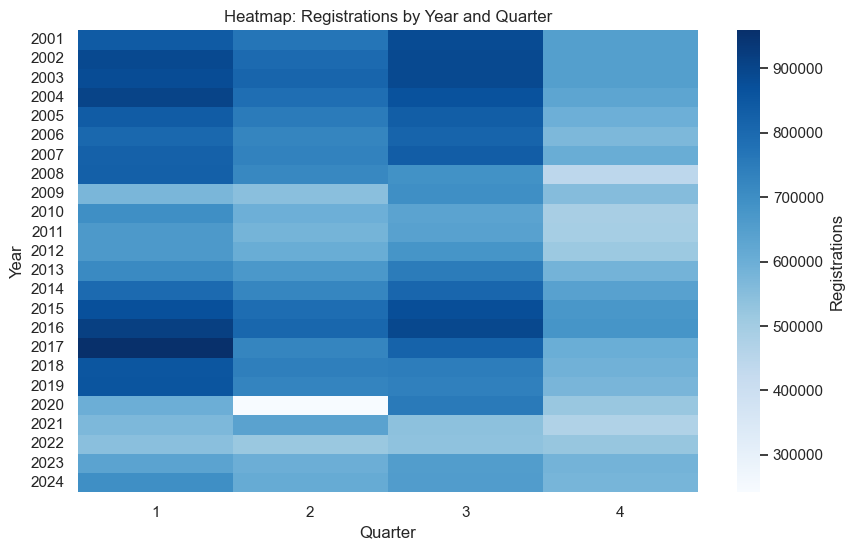

In [28]:
seasonal = (
    result_df.groupby(["Year", "Quarter"])["Registrations"]
    .sum()
    .reset_index()
    .pivot(index="Year", columns="Quarter", values="Registrations")
)

#heatmap
plt.figure(figsize=(10,6))
sns.heatmap(seasonal, annot=False, fmt=".0f", cmap="Blues", cbar_kws={'label': 'Registrations'})
plt.title("Heatmap: Registrations by Year and Quarter")
plt.ylabel("Year")
plt.xlabel("Quarter")
plt.show()

In [29]:
season_stats = (
    quarter
    .groupby('Quarter')['Registrations']
    .agg(
        mean='mean',
        total='sum',
    )
    .reset_index()
)

season_stats.head()

,Quarter,mean,total
0,1,767795.250000,18427086
1,2,675320.541667,16207693
2,3,755799.125000,18139179
3,4,577920.791667,13870099


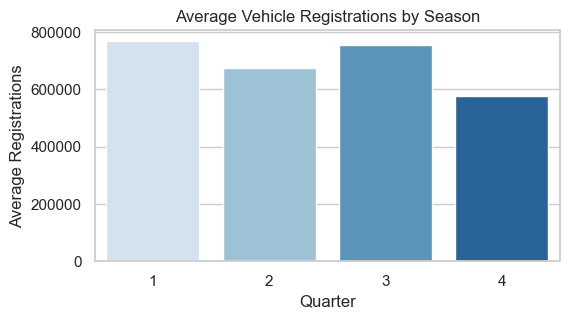

In [30]:
plt.figure(figsize=(6,3))
sns.barplot(data=season_stats, x='Quarter', y='mean', palette='Blues')
plt.title("Average Vehicle Registrations by Season")
plt.ylabel("Average Registrations")
plt.xlabel("Quarter")
plt.show()

- Certain years show strong Q1 or Q3 peaks, reflecting release cycles and consumer demand.
- Q4 tends to be weaker in many years, possibly due to year-end financial factors.
- Anomalies are visible in 2009–2010 (global financial crisis) and 2020 (COVID-19 pandemic), both causing noticeable drops in demand.
- The overall decline of diesel and growth of alternative fuels is visible in the later years, with seasonal fluctuations becoming less pronounced after 2020.
- Seasonality is stable and predictable, which makes it highly relevant for planning sales strategies and forecasting future trends.

# Key Insights

- Annual vehicle registrations fluctuate between 2.5–3.3 million, showing recovery post-pandemic yet below pre-2020 peaks.

- **Economic events** (2008–2009 financial crisis, 2020 COVID-19) caused sharp declines, while seasonal trends (**Q1/Q3 peaks**, weaker Q4) remain predictable for planning.

- **Cars dominate the market**, with commercial vehicles and motorcycles maintaining smaller, stable shares.  

- Fuel transition underway: Diesel peaked in 2015 and declined; hybrids and electric vehicles grew rapidly after 2015, especially post-2020, but **petrol/diesel still dominate**.

- Market leadership: **Ford consistently leads**; Vauxhall, Mercedes, and Volkswagen remain strong, while newcomers like KIA, Audi, Honda, BMW, and Hyundai gain popularity.

Future outlook: Predictable seasonality and growing adoption of alternative fuels indicate opportunities for strategic planning and sustainable market growth.